In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("data\\raw\\NetFlix.csv")
df.shape

(7787, 12)

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='str')

In [5]:
print(df.describe())

print(df.info())

       release_year     duration
count   7787.000000  7787.000000
mean    2013.932580    69.122769
std        8.757395    50.950743
min     1925.000000     1.000000
25%     2013.000000     2.000000
50%     2017.000000    88.000000
75%     2018.000000   106.000000
max     2021.000000   312.000000
<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory 

In [6]:
print("Valori null:\n",df.isnull().sum())

print("Valori duplicati:\n",df.duplicated().sum())



Valori null:
 show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64
Valori duplicati:
 0


In [7]:
df["type"].value_counts()



type
Movie      5377
TV Show    2410
Name: count, dtype: int64

In [8]:
df.head()

df.groupby("country", as_index=False).agg(conta=("country",'size')).sort_values("conta", ascending=False).head(10).reset_index()


,index,country,conta
0,549,United States,2555
1,229,India,923
2,462,United Kingdom,397
3,291,Japan,226
4,394,South Korea,183
5,51,Canada,177
6,403,Spain,134
7,147,France,115
8,137,Egypt,101
9,448,Turkey,100


In [9]:
df["rating"].isnull().sum()

df["country"].isnull().sum()

df["rating"].isnull().sum()



df["country"] = df["country"].fillna(value="country mancante")

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

df["rating"] = df["rating"].fillna(value="rating mancante")


C:\Users\giorg\AppData\Local\Temp\ipykernel_15252\351360191.py:11: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")


In [10]:

df["year_added"] = df["date_added"].dt.year

df["year_added"] = df["year_added"].astype(str).str.replace(".0","")

df["year_added"] = df["year_added"].astype("Int64")

df.head()



,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description,year_added
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,2017-12-15,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...,2017
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,2019-01-05,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...,2019
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,2016-03-01,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...,2016
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,2018-12-03,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...,2018


      type  count
0    Movie   5377
1  TV Show   2410


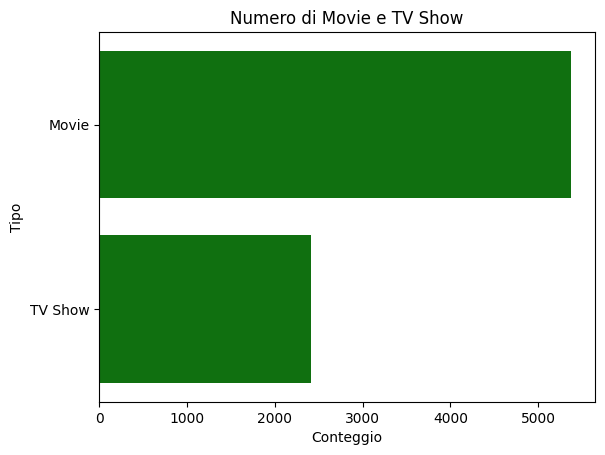

In [ ]:
numero_serie_film = df["type"].value_counts().reset_index()
print(numero_serie_film)


sns.barplot(x="count", y="type", data=numero_serie_film, color="g")
plt.title("Numero di Movie e TV Show")
plt.xlabel("Conteggio")
plt.ylabel("Tipo")
plt.show()


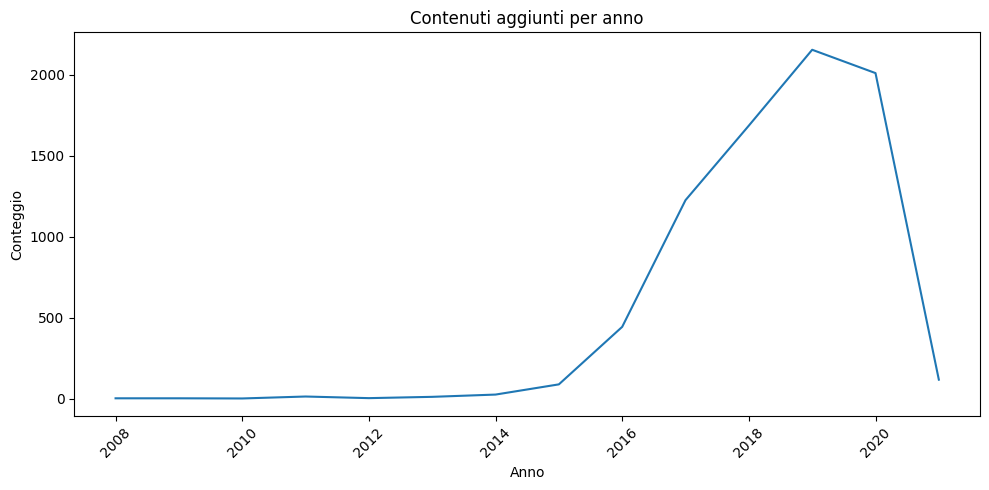

In [ ]:
contenuti_aggiunti_per_anno = df.groupby("year_added", as_index=False)["type"].size()

plt.figure(figsize=(10,5))
ax = sns.lineplot(x="year_added", y="size", data=contenuti_aggiunti_per_anno)

ax.set_title("Contenuti aggiunti per anno")
ax.set_xlabel("Anno")
ax.set_ylabel("Conteggio")

ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


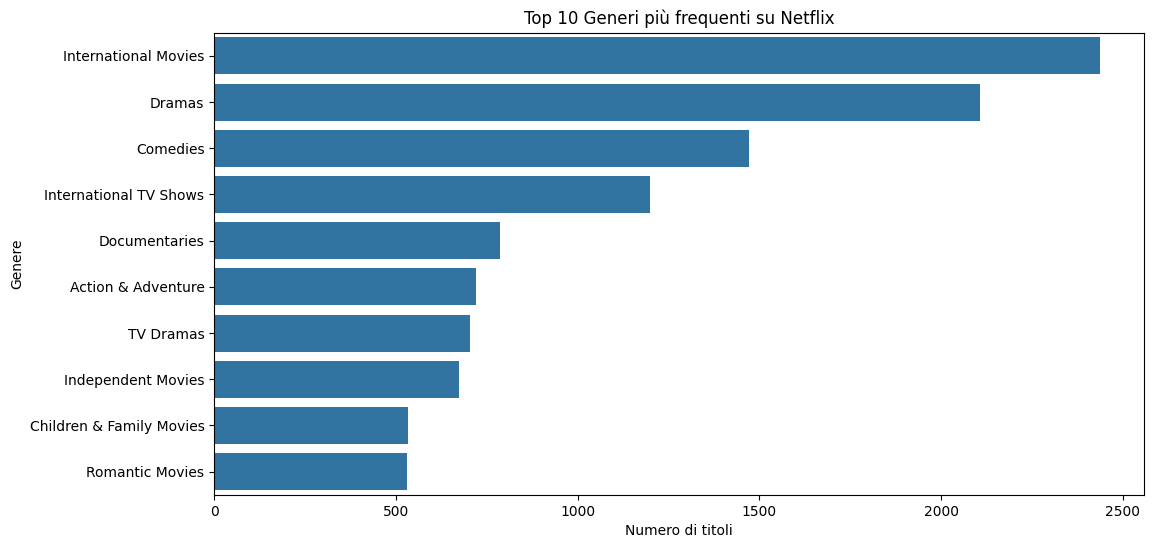

In [ ]:
df['genres_list'] = df['genres'].str.split(',')

genres_exploded = df.explode('genres_list')

genres_exploded['genres_list'] = genres_exploded['genres_list'].str.strip()

genre_counts = genres_exploded['genres_list'].value_counts().head(10)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title("Top 10 Generi più frequenti su Netflix")
plt.xlabel("Numero di titoli")
plt.ylabel("Genere")
plt.show()


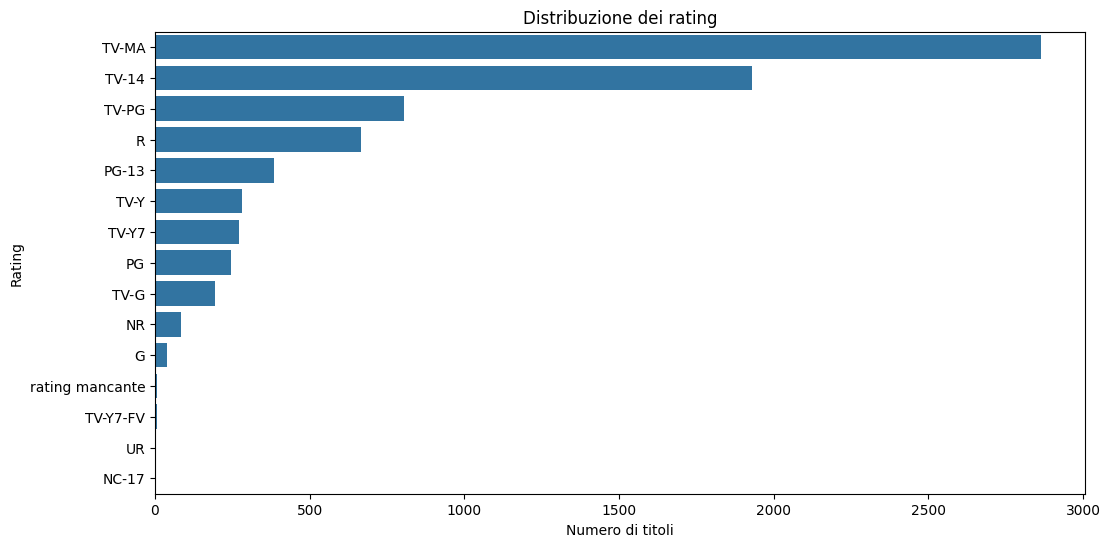

In [ ]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(12,6))
sns.barplot(x=rating_counts.values, y=rating_counts.index)
plt.title("Distribuzione dei rating")
plt.xlabel("Numero di titoli")
plt.ylabel("Rating")
plt.show()


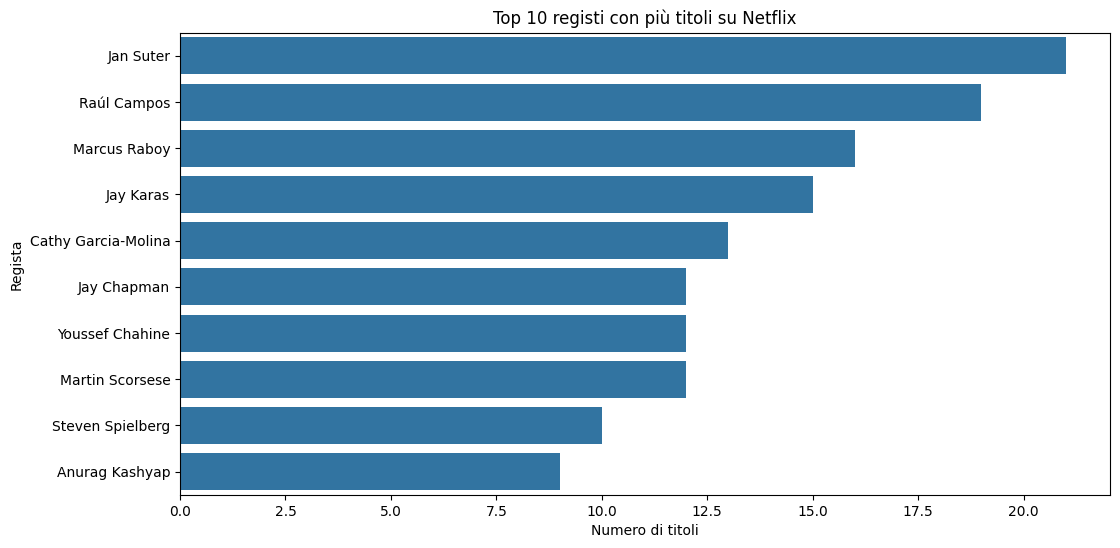

In [ ]:
directors = df['director'].dropna()

directors = directors.str.split(',').explode().str.strip()

top_directors = directors.value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values, y=top_directors.index)
plt.title("Top 10 registi con più titoli su Netflix")
plt.xlabel("Numero di titoli")
plt.ylabel("Regista")
plt.show()


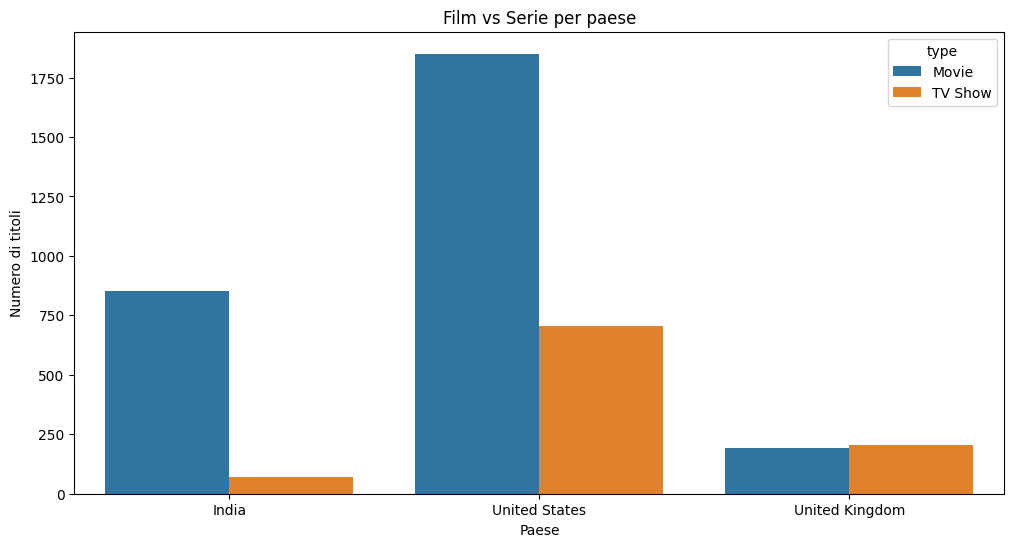

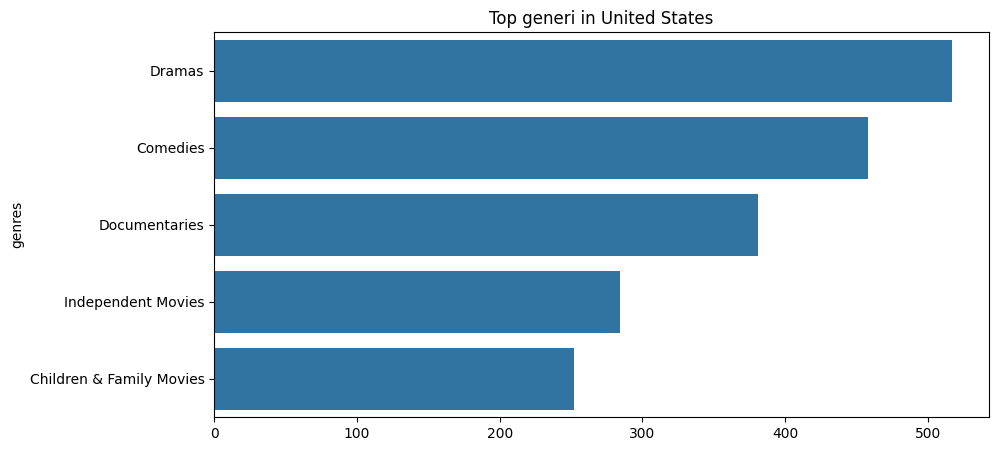

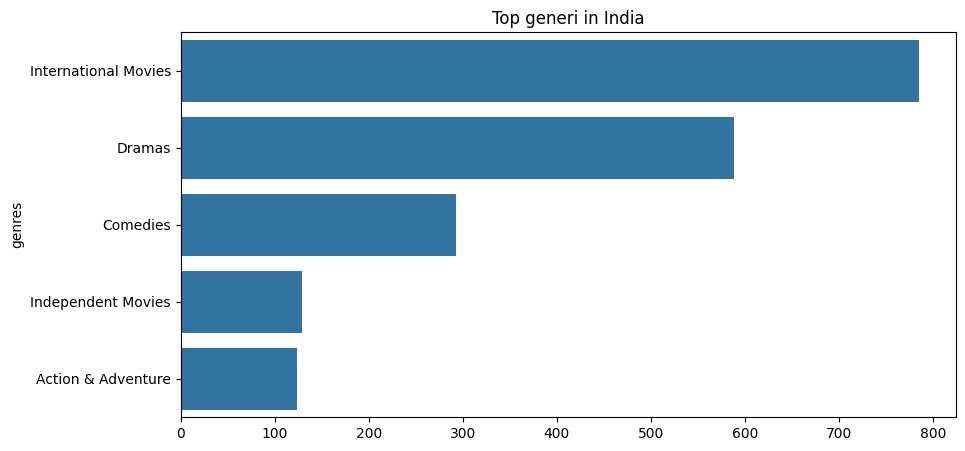

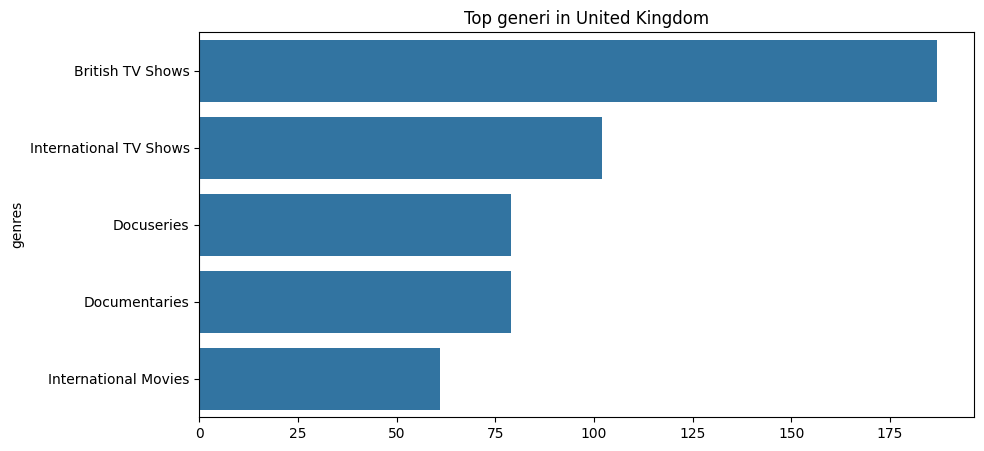

In [ ]:
countries = ['United States', 'India', 'United Kingdom']
df_country = df[df['country'].isin(countries)]

plt.figure(figsize=(12,6))
sns.countplot(data=df_country, x='country', hue='type')
plt.title("Film vs Serie per paese")
plt.xlabel("Paese")
plt.ylabel("Numero di titoli")
plt.show()


for c in countries:
    subset = df_country[df_country['country'] == c]
    subset_genres = subset['genres'].str.split(',').explode().str.strip()
    top_genres = subset_genres.value_counts().head(5)
    plt.figure(figsize=(10,5))
    sns.barplot(x=top_genres.values, y=top_genres.index)
    plt.title(f"Top generi in {c}")
    plt.show()


In [17]:
print("""
1. I generi più frequenti su Netflix includono Drama, Comedy e Documentary.
2. I film sono più numerosi delle serie TV nel catalogo.
3. Le serie TV hanno principalmente 1-2 stagioni.
4. I rating più comuni sono TV-MA e TV-14, indicando contenuti per adulti.
5. Gli Stati Uniti sono il paese più rappresentato, seguiti da India e UK.
6. Il catalogo è cresciuto rapidamente negli ultimi anni.
""")



1. I generi più frequenti su Netflix includono Drama, Comedy e Documentary.
2. I film sono più numerosi delle serie TV nel catalogo.
3. Le serie TV hanno principalmente 1-2 stagioni.
4. I rating più comuni sono TV-MA e TV-14, indicando contenuti per adulti.
5. Gli Stati Uniti sono il paese più rappresentato, seguiti da India e UK.
6. Il catalogo è cresciuto rapidamente negli ultimi anni.

